In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [21]:
# 1. Feature CSV 로드
df = pd.read_csv("../../kafka_streams/feature_topic_samples/feature_line_jam_s03.csv", parse_dates=["timestamp"])
df.head()

,timestamp,run_count,idle_count,hold_count,manual_mode_count,alarm_count,alarm_rate,production_interval_avg,production_interval_std,good_count,reject_count,reject_rate,reject_streak
0,2026-03-03 08:19:10+00:00,3,2,1,1,4,0.666667,222.5,182.671153,5,0,0.0,0
1,2026-03-03 08:21:50+00:00,3,2,1,1,4,0.666667,222.5,182.671153,5,0,0.0,0
2,2026-03-03 08:24:30+00:00,0,0,0,0,0,0.000000,130.0,46.368092,5,0,0.0,0
3,2026-03-03 08:27:10+00:00,0,0,0,0,0,0.000000,157.5,4.330127,5,0,0.0,0
4,2026-03-03 08:29:50+00:00,0,0,0,0,0,0.000000,160.0,0.000000,5,0,0.0,0


In [ ]:
# 규칙 기반 이상 감지 (Conveyor 기준)
df['rule_alert'] = 0

# total_states 0 방지
total_states = df['run_count'] + df['idle_count'] + df['hold_count']
total_states = total_states.replace(0, 1)  # 0이면 1로 바꿔서 나누기 안전하게

# HOLD / IDLE 비율 계산
df['hold_rate'] = df['hold_count'] / total_states
df['idle_rate'] = df['idle_count'] / total_states
df['alarm_rate_safe'] = df['alarm_count'] / total_states  # 알람 비율도 50% 이상이면 경고

# 1) HOLD 비율 >= 50%
df.loc[df['hold_rate'] >= 0.5, 'rule_alert'] = 1

# 2) IDLE 비율 >= 50%
df.loc[df['idle_rate'] >= 0.5, 'rule_alert'] = 1

# 3) ALARM 발생 비율 >= 50%
df.loc[df['alarm_rate_safe'] >= 0.5, 'rule_alert'] = 1

# 4) MANUAL 모드 전환 과다 (>=2회)
df.loc[df['manual_mode_count'] >= 2, 'rule_alert'] = 1

# 5) Reject streak 2 이상 → 경고
df.loc[df['reject_streak'] >= 2, 'rule_alert'] = 1

# 6) 사이클 지연 > 10% → 경고
df.loc[df['cycle_time_avg'] > 150*1.1, 'rule_alert'] = 1

In [23]:
# 통계 기반 이상 감지
features = ['production_interval_avg','reject_count','alarm_count']
window = 5

for col in features:
    df[f'{col}_mean'] = df[col].shift(1).rolling(window).mean()
    df[f'{col}_std'] = df[col].shift(1).rolling(window).std().replace(0, 1e-6)
    df[f'{col}_zscore'] = np.abs(df[col] - df[f'{col}_mean']) / df[f'{col}_std']
    df[f'{col}_zscore'] = df[f'{col}_zscore'].fillna(0)

# threshold = 2
df['stat_alert'] = (df[[f'{col}_zscore' for col in features]] > 2).any(axis=1).astype(int)


# 통합 이상 알람
df['combined_alert'] = df[['rule_alert','stat_alert']].max(axis=1)

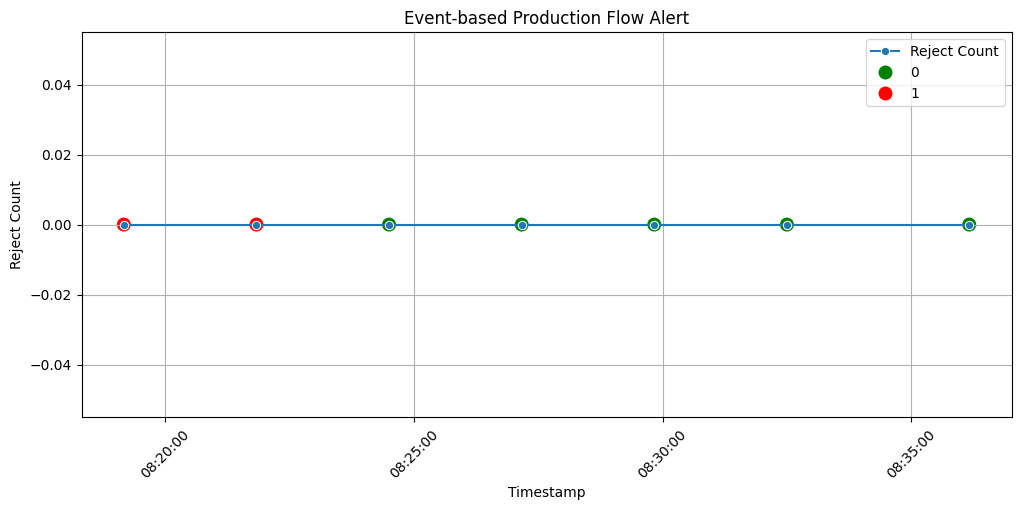

In [24]:
# 시각화
plt.figure(figsize=(12,5))
sns.lineplot(data=df, x='timestamp', y='reject_count', marker='o', label='Reject Count')
sns.scatterplot(data=df, x='timestamp', y='reject_count', hue='combined_alert',
                palette={0:'green',1:'red'}, s=120)

plt.title("Event-based Production Flow Alert")
plt.xlabel("Timestamp")
plt.ylabel("Reject Count")
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)
plt.show()

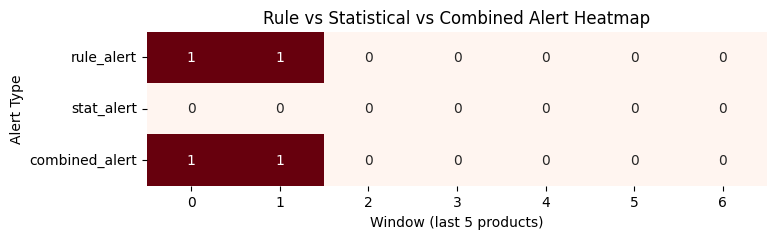

In [25]:
# 히트맵: Rule vs Statistical Alert 비교
alert_map = df[['rule_alert','stat_alert','combined_alert']].T
plt.figure(figsize=(8,2))
sns.heatmap(alert_map, annot=True, cmap='Reds', cbar=False)
plt.title("Rule vs Statistical vs Combined Alert Heatmap")
plt.xlabel("Window (last 5 products)") 
plt.ylabel("Alert Type")
plt.show()